В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [2]:
import matplotlib
from sklearn.metrics import roc_auc_score, classification_report

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

RANDOM_STATE = 42

raw_df = pd.read_csv('train.csv')

print(raw_df.shape)
print()
print(raw_df.dtypes)
print()
print(raw_df.isna().sum())

raw_df.head()

(15000, 14)

id                   int64
CustomerId         float64
Surname             object
CreditScore        float64
Geography           object
Gender              object
Age                float64
Tenure             float64
Balance            float64
NumOfProducts      float64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited             float64
dtype: object

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [3]:
target_col = 'Exited'
input_cols = [col for col in raw_df.columns if col not in ['id', 'CustomerId', 'Surname', target_col]]

train_df, val_df = split_train_val(raw_df, target_col, test_size=0.2, random_state=RANDOM_STATE)

train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, target_col)

print('Ознаки:', input_cols)
print()
print('train_inputs:', train_inputs.shape, '| val_inputs:', val_inputs.shape)
print()
print('Баланс класів в тренувальному наборі:')
print(train_targets.value_counts(normalize=True))

Ознаки: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

train_inputs: (12000, 10) | val_inputs: (3000, 10)

Баланс класів в тренувальному наборі:
Exited
0.0    0.7965
1.0    0.2035
Name: proportion, dtype: float64


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [4]:
cat_features = train_inputs.select_dtypes(include='object').columns

train_inputs[cat_features] = train_inputs[cat_features].astype('category')
val_inputs[cat_features] = val_inputs[cat_features].astype('category')

print('Категоріальні ознаки:', list(cat_features))
print()
print(train_inputs.dtypes)

Категоріальні ознаки: ['Geography', 'Gender']

CreditScore         float64
Geography          category
Gender             category
Age                 float64
Tenure              float64
Balance             float64
NumOfProducts       float64
HasCrCard           float64
IsActiveMember      float64
EstimatedSalary     float64
dtype: object


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [6]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    enable_categorical=True,  # для категорійних ознак
    missing=np.nan,  # вказування пропущених значень
    random_state=RANDOM_STATE,
    device='cuda'
)

xgb_clf.fit(train_inputs, train_targets)

train_probs = xgb_clf.predict_proba(train_inputs)[:, 1]
val_probs = xgb_clf.predict_proba(val_inputs)[:, 1]

print('AUROC train: {:.4f}'.format(roc_auc_score(train_targets, train_probs)))
print('AUROC val:   {:.4f}'.format(roc_auc_score(val_targets, val_probs)))

AUROC train: 0.9386
AUROC val:   0.9366


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [22:32:10] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


### Висновок до завдання 2

Базова модель `XGBClassifier` з простими параметрами (`max_depth=3`, `n_estimators=50`, `learning_rate=0.1`) дає:
- AUROC на тренувальній вибірці: **0.9386**
- AUROC на валідаційній вибірці: **0.9366**

Різниця між тренувальним і валідаційним скором становить лише 0.002, тобто **high variance (перенавчання) відсутнє** — модель добре узагальнює. Оскільки модель проста, можна припустити наявність незначного high bias: є простір для ускладнення моделі та підбору гіперпараметрів.

Порівняно з рішенням на `DecisionTreeClassifier`, отриманим раніше, бустинг дає кращу і значно стабільнішу якість: одиночне дерево схильне до сильного перенавчання, тоді як ансамбль неглибоких дерев із малим learning rate тримає розрив train/val мінімальним.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [7]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials


def objective(params):
    clf = XGBClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак для побудови кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        missing=np.nan,
        random_state=RANDOM_STATE,
        device='cuda'
    )

    clf.fit(train_inputs, train_targets)
    probs = clf.predict_proba(val_inputs)[:, 1]
    auroc = roc_auc_score(val_targets, probs)

    return {'loss': -auroc, 'status': STATUS_OK}


# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

100%|██████████| 20/20 [00:09<00:00,  2.22trial/s, best loss: -0.9358625420124838]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.8220426653625877), 'gamma': np.float64(0.44386253421010957), 'learning_rate': np.float64(0.059554991393287425), 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 175, 'reg_alpha': np.float64(0.8620847406307888), 'reg_lambda': np.float64(0.8049454382374343), 'subsample': np.float64(0.8801203292827047)}


In [8]:
final_clf = XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    missing=np.nan,
    random_state=RANDOM_STATE,
    device='cuda'
)

final_clf.fit(train_inputs, train_targets)

train_probs = final_clf.predict_proba(train_inputs)[:, 1]
val_probs = final_clf.predict_proba(val_inputs)[:, 1]

print('final_clf AUROC train: {:.4f}'.format(roc_auc_score(train_targets, train_probs)))
print('final_clf AUROC val:   {:.4f}'.format(roc_auc_score(val_targets, val_probs)))

final_clf AUROC train: 0.9505
final_clf AUROC val:   0.9359


### Висновок до завдання 3

Пошук гіперпараметрів з `Hyperopt` (20 раундів, TPE, loss = негативний AUROC на валідації) дав такі найкращі параметри: `max_depth=4`, `n_estimators=175`, `learning_rate=0.0596`, `subsample=0.88`, `colsample_bytree=0.82`, `gamma=0.444`, `reg_alpha=0.862`, `reg_lambda=0.805`.

Результати моделі `final_clf`:
- AUROC на тренувальній вибірці: **0.9505**
- AUROC на валідаційній вибірці: **0.9359**

Порівняно з базовою моделлю з завдання 2 (train 0.9386 / val 0.9366) якість на валідації **не покращилась, а навіть трохи знизилась**, тоді як на тренувальній вибірці зросла. Розрив між train і val збільшився з 0.002 до 0.015 — тобто підібрана модель складніша і починає перенавчатись.


4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [9]:
import lightgbm as lgb

cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_features]

lgb_clf = lgb.LGBMClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    cat_feature=cat_feature_indexes,  # для автоматичного розпізнавання категорійних ознак
    missing=np.nan,  # явне вказування пропущених значень
    random_state=RANDOM_STATE,
    verbose=-1
)

lgb_clf.fit(train_inputs, train_targets)

train_probs = lgb_clf.predict_proba(train_inputs)[:, 1]
val_probs = lgb_clf.predict_proba(val_inputs)[:, 1]

print('Індекси категоріальних ознак:', cat_feature_indexes)
print()
print('lgb_clf AUROC train: {:.4f}'.format(roc_auc_score(train_targets, train_probs)))
print('lgb_clf AUROC val:   {:.4f}'.format(roc_auc_score(val_targets, val_probs)))

Індекси категоріальних ознак: [1, 2]

lgb_clf AUROC train: 0.9388
lgb_clf AUROC val:   0.9362


### Висновок до завдання 4

Базова модель `LGBMClassifier` з аналогічними до XGBoost параметрами (`max_depth=3`, `n_estimators=50`, `learning_rate=0.1`) дає:
- AUROC на тренувальній вибірці: **0.9388**
- AUROC на валідаційній вибірці: **0.9362**

Розрив train/val становить 0.0026 — **high variance відсутній**, модель добре узагальнює. Як і у випадку XGBoost, модель проста, тому може мати незначний high bias.


5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [10]:
def evaluate_model(clf):
    """Навчає модель і повертає негативний AUROC на валідації для hyperopt."""
    clf.fit(train_inputs, train_targets)
    probs = clf.predict_proba(val_inputs)[:, 1]
    return {'loss': -roc_auc_score(val_targets, probs), 'status': STATUS_OK}


def objective_lgb(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі
        learning_rate=params['learning_rate'],  # Коефіцієнт зменшення внеску кожного дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків дерева
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак для побудови кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат для поділу
        cat_feature=cat_feature_indexes,
        random_state=RANDOM_STATE,
        verbose=-1
    )

    return evaluate_model(clf)


# Простір гіперпараметрів
space_lgb = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)
}

# Оптимізація
trials_lgb = Trials()
best_lgb = fmin(fn=objective_lgb, space=space_lgb, algo=tpe.suggest, max_evals=10, trials=trials_lgb)

# Перетворення значень гіперпараметрів у кінцеві типи
best_lgb['n_estimators'] = int(best_lgb['n_estimators'])
best_lgb['max_depth'] = int(best_lgb['max_depth'])
best_lgb['num_leaves'] = int(best_lgb['num_leaves'])
best_lgb['min_child_weight'] = int(best_lgb['min_child_weight'])

print("Найкращі гіперпараметри LightGBM: ", best_lgb)

100%|██████████| 10/10 [00:06<00:00,  1.64trial/s, best loss: -0.9347678167226834]
Найкращі гіперпараметри LightGBM:  {'colsample_bytree': np.float64(0.9212664591576138), 'learning_rate': np.float64(0.038112915945893874), 'max_depth': 5, 'min_child_weight': 9, 'min_split_gain': np.float64(0.09355911345204437), 'n_estimators': 375, 'num_leaves': 102, 'reg_alpha': np.float64(0.9677471493231817), 'reg_lambda': np.float64(0.38697802427274386), 'subsample': np.float64(0.8397470246066612)}


In [11]:
final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=best_lgb['n_estimators'],
    learning_rate=best_lgb['learning_rate'],
    max_depth=best_lgb['max_depth'],
    num_leaves=best_lgb['num_leaves'],
    min_child_weight=best_lgb['min_child_weight'],
    subsample=best_lgb['subsample'],
    colsample_bytree=best_lgb['colsample_bytree'],
    reg_alpha=best_lgb['reg_alpha'],
    reg_lambda=best_lgb['reg_lambda'],
    min_split_gain=best_lgb['min_split_gain'],
    cat_feature=cat_feature_indexes,
    random_state=RANDOM_STATE,
    verbose=-1
)

final_lgb_clf.fit(train_inputs, train_targets)

train_probs = final_lgb_clf.predict_proba(train_inputs)[:, 1]
val_probs = final_lgb_clf.predict_proba(val_inputs)[:, 1]

print('final_lgb_clf AUROC train: {:.4f}'.format(roc_auc_score(train_targets, train_probs)))
print('final_lgb_clf AUROC val:   {:.4f}'.format(roc_auc_score(val_targets, val_probs)))

final_lgb_clf AUROC train: 0.9586
final_lgb_clf AUROC val:   0.9348


### Висновок до завдання 5

Пошук гіперпараметрів з `Hyperopt` (10 раундів, loss = негативний AUROC) дав: `max_depth=5`, `num_leaves=102`, `n_estimators=375`, `learning_rate=0.0381`, `min_child_weight=9`, `subsample=0.84`, `colsample_bytree=0.92`, `reg_alpha=0.968`, `reg_lambda=0.387`, `min_split_gain=0.094`.

Результати моделі `final_lgb_clf`:
- AUROC на тренувальній вибірці: **0.9586**
- AUROC на валідаційній вибірці: **0.9348**

Порівняно з базовою моделлю з завдання 4 (train 0.9388 / val 0.9362) якість на валідації **знизилась**, а розрив між train і val зріс з 0.0026 до 0.0238 — це найбільший розрив серед усіх моделей роботи. Комбінація `num_leaves=102` та 375 ітерацій зробила модель надмірно гнучкою: вона добре запам'ятала тренувальні дані, але узагальнює гірше.


6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [14]:
test_inputs = test_df[input_cols].copy()
test_inputs[cat_features] = test_inputs[cat_features].astype('category')

test_probs = xgb_clf.predict_proba(test_inputs)[:, 1]

submission_df = sample_submission_df.copy()
submission_df['Exited'] = test_probs

submission_df.to_csv('submission.csv', index=False)

print(submission_df.shape)
print()
print(submission_df['Exited'].describe())

submission_df.head()

(10000, 2)

count    10000.000000
mean         0.209442
std          0.281122
min          0.010047
25%          0.021026
50%          0.066559
75%          0.251325
max          0.989153
Name: Exited, dtype: float64


,id,Exited
0,15000,0.094201
1,15001,0.025796
2,15002,0.070490
3,15003,0.514701
4,15004,0.049312


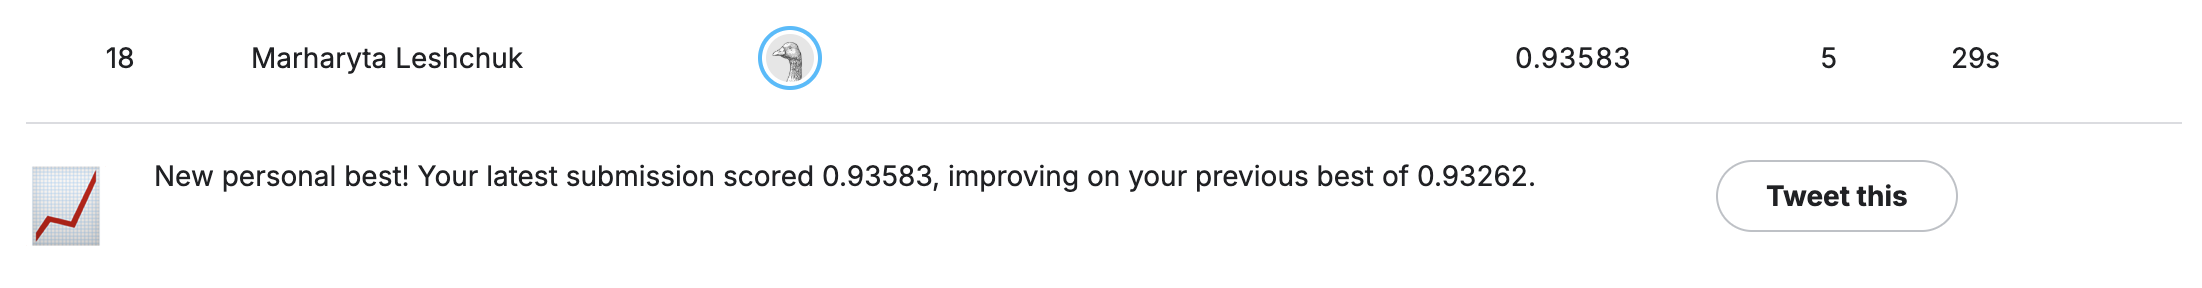

### Висновок до завдання 6

Для фінального submission обрано **базову модель `XGBClassifier`** (`max_depth=3`, `n_estimators=50`, `learning_rate=0.1`).



1. Вона показала **найкращий AUROC на валідаційній вибірці — 0.9366** серед усіх чотирьох експериментів роботи.
2. У неї **найменший розрив між train і val (0.0020)**, тобто вона найкраще узагальнює і найменш схильна до перенавчання. Тюнінговані моделі мали вищий скор на тренувальних даних, але гірший на валідації — це ознака того, що вони почали запам'ятовувати дані замість вивчення закономірностей.


